# **TD control methods for Cliff Walking**


### **Assignment 7 - Reinforcement Learning - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

alpha=0.10 done
alpha=0.15 done
alpha=0.20 done
alpha=0.25 done
alpha=0.30 done
alpha=0.35 done
alpha=0.40 done
alpha=0.45 done
alpha=0.50 done
alpha=0.55 done
alpha=0.60 done
alpha=0.65 done
alpha=0.70 done
alpha=0.75 done
alpha=0.80 done
alpha=0.85 done
alpha=0.90 done
alpha=0.95 done
alpha=1.00 done


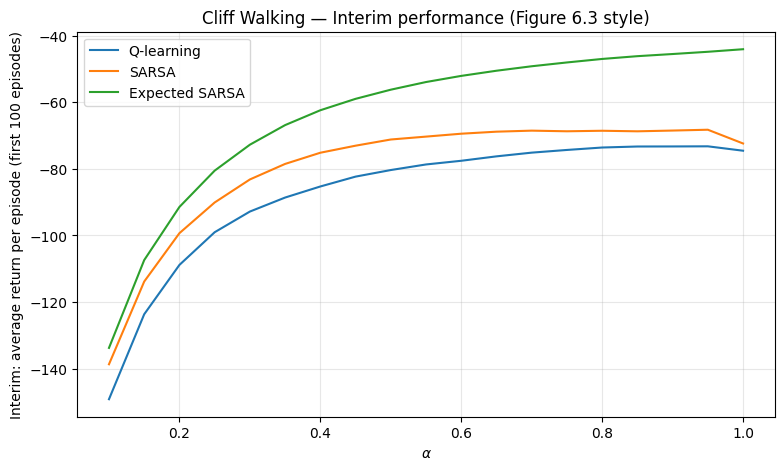

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Cliff Walking environment
# ----------------------------
WIDTH, HEIGHT = 12, 4
START = (0, 0)
GOAL  = (11, 0)
CLIFF = {(x, 0) for x in range(1, 11)}  # (1..10, 0)

A_LEFT, A_RIGHT, A_UP, A_DOWN = 0, 1, 2, 3
ACTIONS = [A_LEFT, A_RIGHT, A_UP, A_DOWN]

def step(state, action):
    """Returns next_state, reward, done."""
    x, y = state

    if action == A_LEFT:
        x2, y2 = max(x - 1, 0), y
    elif action == A_RIGHT:
        x2, y2 = min(x + 1, WIDTH - 1), y
    elif action == A_UP:
        x2, y2 = x, min(y + 1, HEIGHT - 1)
    elif action == A_DOWN:
        x2, y2 = x, max(y - 1, 0)
    else:
        raise ValueError("Unknown action")

    next_state = (x2, y2)

    # cliff
    if next_state in CLIFF:
        return START, -100, False

    # normal transition
    if next_state == GOAL:
        return next_state, -1, True

    return next_state, -1, False

def epsilon_greedy(Q, s, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(0, len(ACTIONS)))
    qs = Q[s[0], s[1], :]
    best = np.flatnonzero(qs == np.max(qs))
    return int(rng.choice(best))

# ----------------------------
# Algorithms
# ----------------------------
def run_sarsa(alpha, epsilon=0.1, gamma=1.0, episodes=100, max_len=500, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((WIDTH, HEIGHT, len(ACTIONS)), dtype=float)
    returns = np.zeros(episodes, dtype=float)

    for ep in range(episodes):
        s = START
        a = epsilon_greedy(Q, s, epsilon, rng)
        G = 0.0

        for _ in range(max_len):
            sp, r, done = step(s, ACTIONS[a])
            G += r
            if done:
                # terminal: SARSA target = r
                Q[s[0], s[1], a] += alpha * (r - Q[s[0], s[1], a])
                break
            ap = epsilon_greedy(Q, sp, epsilon, rng)
            td = r + gamma * Q[sp[0], sp[1], ap] - Q[s[0], s[1], a]
            Q[s[0], s[1], a] += alpha * td
            s, a = sp, ap

        returns[ep] = G

    return returns

def run_qlearning(alpha, epsilon=0.1, gamma=1.0, episodes=100, max_len=500, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((WIDTH, HEIGHT, len(ACTIONS)), dtype=float)
    returns = np.zeros(episodes, dtype=float)

    for ep in range(episodes):
        s = START
        G = 0.0

        for _ in range(max_len):
            a = epsilon_greedy(Q, s, epsilon, rng)
            sp, r, done = step(s, ACTIONS[a])
            G += r
            if done:
                Q[s[0], s[1], a] += alpha * (r - Q[s[0], s[1], a])
                break
            td = r + gamma * np.max(Q[sp[0], sp[1], :]) - Q[s[0], s[1], a]
            Q[s[0], s[1], a] += alpha * td
            s = sp

        returns[ep] = G

    return returns

def run_expected_sarsa(alpha, epsilon=0.1, gamma=1.0, episodes=100, max_len=500, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((WIDTH, HEIGHT, len(ACTIONS)), dtype=float)
    returns = np.zeros(episodes, dtype=float)

    for ep in range(episodes):
        s = START
        G = 0.0

        for _ in range(max_len):
            a = epsilon_greedy(Q, s, epsilon, rng)
            sp, r, done = step(s, ACTIONS[a])
            G += r
            if done:
                Q[s[0], s[1], a] += alpha * (r - Q[s[0], s[1], a])
                break

            # expected value under epsilon-greedy policy at sp
            qs = Q[sp[0], sp[1], :]
            best = np.flatnonzero(qs == np.max(qs))
            pi = np.ones(len(ACTIONS)) * (epsilon / len(ACTIONS))
            pi[best] += (1.0 - epsilon) / len(best)
            expected_q = np.sum(pi * qs)

            td = r + gamma * expected_q - Q[s[0], s[1], a]
            Q[s[0], s[1], a] += alpha * td
            s = sp

        returns[ep] = G

    return returns

# ----------------------------
# Interim experiment
# ----------------------------
def interim_curve(num_runs=2000, episodes=100, max_len=500, epsilon=0.1, gamma=1.0):
    alphas = np.linspace(0.1, 1.0, 19)

    sarsa_vals = []
    ql_vals    = []
    exp_vals   = []

    for alpha in alphas:
        sarsa_runs = []
        ql_runs    = []
        exp_runs   = []

        for run in range(num_runs):
            seed = run  # different seed per run
            sarsa_ret = run_sarsa(alpha, epsilon, gamma, episodes, max_len, seed)
            ql_ret    = run_qlearning(alpha, epsilon, gamma, episodes, max_len, seed)
            exp_ret   = run_expected_sarsa(alpha, epsilon, gamma, episodes, max_len, seed)

            # interim = average return over first 100 episodes
            sarsa_runs.append(np.mean(sarsa_ret))
            ql_runs.append(np.mean(ql_ret))
            exp_runs.append(np.mean(exp_ret))

        sarsa_vals.append(np.mean(sarsa_runs))
        ql_vals.append(np.mean(ql_runs))
        exp_vals.append(np.mean(exp_runs))

        print(f"alpha={alpha:.2f} done")

    return alphas, np.array(sarsa_vals), np.array(ql_vals), np.array(exp_vals)

alphas, sarsa_y, ql_y, exp_y = interim_curve(num_runs=2000)  # we could put 50.000 but it would take time

plt.figure(figsize=(9,5))
plt.plot(alphas, ql_y, label="Q-learning")
plt.plot(alphas, sarsa_y, label="SARSA")
plt.plot(alphas, exp_y, label="Expected SARSA")
plt.xlabel(r"$\alpha$")
plt.ylabel("Interim: average return per episode (first 100 episodes)")
plt.title("Cliff Walking - Interim performance (Figure 6.3 style)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()